In [1]:
# Import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from scipy import stats

In [2]:
# Load and Inspect Dataset

df = pd.read_csv("recipe_site_traffic_2212.csv")

print("Dataset shape:", df.shape)
print("\nPreview:\n", df.head())
print("\nMissing values:\n", df.isna().sum())


Dataset shape: (947, 8)

Preview:
    recipe  calories  carbohydrate  sugar  protein   category servings  \
0       1       NaN           NaN    NaN      NaN       Pork        6   
1       2     35.48         38.56   0.66     0.92     Potato        4   
2       3    914.28         42.68   3.09     2.88  Breakfast        1   
3       4     97.03         30.56  38.63     0.02  Beverages        4   
4       5     27.05          1.85   0.80     0.53  Beverages        4   

  high_traffic  
0         High  
1         High  
2          NaN  
3         High  
4          NaN  

Missing values:
 recipe            0
calories         52
carbohydrate     52
sugar            52
protein          52
category          0
servings          0
high_traffic    373
dtype: int64


In [3]:
# DATA VALIDATION AND CLEANING

#  Convert 'recipe' to numeric and ensure uniqueness
df['recipe'] = pd.to_numeric(df['recipe'], errors='coerce')
print("Unique recipe IDs:", df['recipe'].nunique())

#  Convert numeric columns to numeric data types
numeric_cols = ['calories', 'carbohydrate', 'sugar', 'protein', 'servings']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

#  Impute missing numeric values by category median (context-aware imputation)
if 'category' in df.columns:
    for col in ['calories', 'carbohydrate', 'sugar', 'protein']:
        df[col] = df.groupby('category')[col].transform(lambda x: x.fillna(x.median()))

#  Standardize text variables
text_cols = ['category', 'high_traffic']
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()

#  Clean and convert the 'servings' column to numeric
df['servings'] = (
    df['servings']
    .astype(str)
    .str.extract('(\d+)')   # Extract numeric part (ignore text like "as a snack")
    .astype(float)
)

#  Impute missing 'servings' by category median
df['servings'] = df.groupby('category')['servings'].transform(lambda x: x.fillna(x.median()))

#  Final validation checks
print("\n Data Validation Summary")
print("Dataset Shape:", df.shape)
print("\nColumn Data Types:\n", df.dtypes)
print("\nMissing Values per Column:\n", df.isna().sum())
print("\nDuplicate Recipe IDs:", df['recipe'].duplicated().sum())
print("\nPreview of Cleaned Dataset:")
print(df.head())


Unique recipe IDs: 947

 Data Validation Summary
Dataset Shape: (947, 8)

Column Data Types:
 recipe            int64
calories        float64
carbohydrate    float64
sugar           float64
protein         float64
category            str
servings        float64
high_traffic        str
dtype: object

Missing Values per Column:
 recipe            0
calories          0
carbohydrate      0
sugar             0
protein           0
category          0
servings          0
high_traffic    373
dtype: int64

Duplicate Recipe IDs: 0

Preview of Cleaned Dataset:
   recipe  calories  carbohydrate  sugar  protein   category  servings  \
0       1    399.26         19.56   5.23    29.82       pork       6.0   
1       2     35.48         38.56   0.66     0.92     potato       4.0   
2       3    914.28         42.68   3.09     2.88  breakfast       1.0   
3       4     97.03         30.56  38.63     0.02  beverages       4.0   
4       5     27.05          1.85   0.80     0.53  beverages       4.0   


<>:27: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:27: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\AYO\AppData\Local\Temp\ipykernel_5396\3678352426.py:27: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  .str.extract('(\d+)')   # Extract numeric part (ignore text like "as a snack")


In [4]:
from scipy import stats

# Detect and remove extreme outliers using z-score
z = np.abs(stats.zscore(df[numeric_cols]))
df = df[(z < 3).all(axis=1)]
print("\nData shape after outlier removal:", df.shape)



Data shape after outlier removal: (874, 8)


In [5]:
#  Fix Target Column ('high_traffic')

# 'high_traffic' contains 'high' and NaN -> treat NaN as 'low' (not high traffic)
df['high_traffic'] = df['high_traffic'].apply(lambda x: 'high' if str(x).lower() == 'high' else 'low')

# Encode binary labels: high = 1, low = 0
df['high_traffic_label'] = df['high_traffic'].map({'low': 0, 'high': 1})
# Confirm encoding
print("\nTarget variable distribution:\n", df['high_traffic_label'].value_counts())



Target variable distribution:
 high_traffic_label
1    524
0    350
Name: count, dtype: int64


In [6]:
# Check for Missing Values
print("\nFinal Missing Values:\n", df.isna().sum())
print("\nData Types:\n", df.dtypes)
print("\nPreview of Cleaned Data:\n", df.head())



Final Missing Values:
 recipe                0
calories              0
carbohydrate          0
sugar                 0
protein               0
category              0
servings              0
high_traffic          0
high_traffic_label    0
dtype: int64

Data Types:
 recipe                  int64
calories              float64
carbohydrate          float64
sugar                 float64
protein               float64
category                  str
servings              float64
high_traffic              str
high_traffic_label      int64
dtype: object

Preview of Cleaned Data:
    recipe  calories  carbohydrate  sugar  protein   category  servings  \
0       1    399.26         19.56   5.23    29.82       pork       6.0   
1       2     35.48         38.56   0.66     0.92     potato       4.0   
2       3    914.28         42.68   3.09     2.88  breakfast       1.0   
3       4     97.03         30.56  38.63     0.02  beverages       4.0   
4       5     27.05          1.85   0.80     0.53  b

In [7]:
# Assign cleaned data to variable for further analysis 
clean_df = df.copy()
print("\n✅ clean_df successfully created. Shape:", clean_df.shape)


✅ clean_df successfully created. Shape: (874, 9)


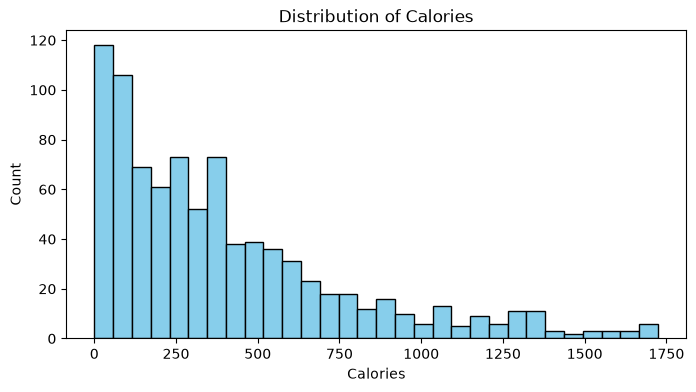

In [8]:
# Exploratory Data Analysis (EDA)

#  Calories distribution (Single Variable)
plt.figure(figsize=(8,4))
plt.hist(clean_df['calories'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Calories")
plt.xlabel("Calories")
plt.ylabel("Count")
plt.show()



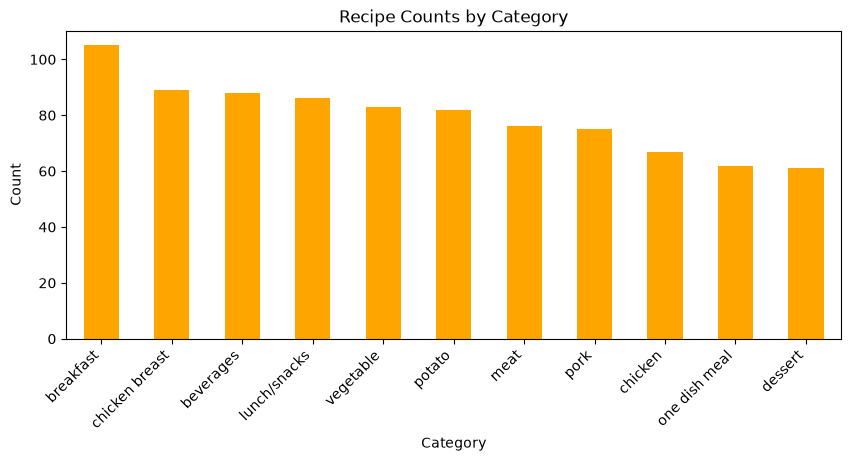

In [9]:
#  Category frequency (Single Variable)
plt.figure(figsize=(10,4))
clean_df['category'].value_counts().plot(kind='bar', color='orange')
plt.title("Recipe Counts by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()



<Figure size 600x500 with 0 Axes>

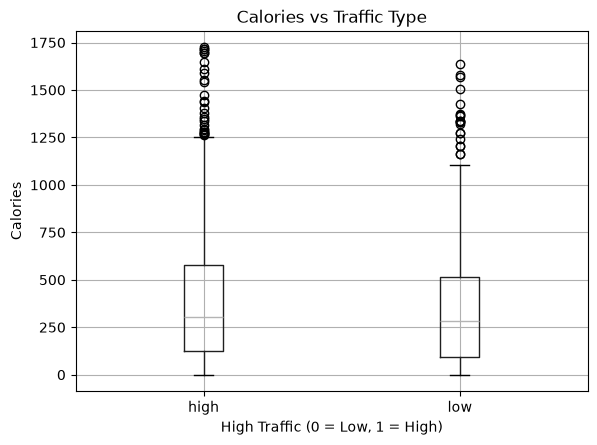

In [10]:
#  Calories vs High Traffic (Multi-varibale)
plt.figure(figsize=(6,5))
clean_df.boxplot(column='calories', by='high_traffic')
plt.title("Calories vs Traffic Type")
plt.suptitle('')
plt.xlabel("High Traffic (0 = Low, 1 = High)")
plt.ylabel("Calories")
plt.show()

In [11]:
#  MODEL DEVELOPMENT
#  Classification (Predicting High Traffic or Not)

# Prepare Features and Target

X = clean_df[['calories', 'carbohydrate', 'sugar', 'protein', 'servings', 'category']]
y = clean_df['high_traffic_label']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


#  Preprocessing Pipelines

numeric_features = ['calories', 'carbohydrate', 'sugar', 'protein', 'servings']
categorical_features = ['category']

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


# Define Models

lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])


# Train both Models

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['calories','carbohydrate','sugar','protein','servings','category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all r

In [12]:
#  MODEL EVALUATION

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba)
    }
    
    print(f"\n{name} Performance Metrics:")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    return metrics


# Evaluate Models
metrics_logreg = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")
metrics_rf = evaluate_model(rf_model, X_test, y_test, "Random Forest")



Logistic Regression Performance Metrics:
Accuracy: 0.7886
Precision: 0.8091
Recall: 0.8476
F1 Score: 0.8279
ROC AUC: 0.8498

Confusion Matrix:
[[49 21]
 [16 89]]

Random Forest Performance Metrics:
Accuracy: 0.7029
Precision: 0.7677
Recall: 0.7238
F1 Score: 0.7451
ROC AUC: 0.8213

Confusion Matrix:
[[47 23]
 [29 76]]


In [13]:
# Compare Results
results_df = pd.DataFrame([metrics_logreg, metrics_rf], index=['Logistic Regression', 'Random Forest'])
print("\nModel Comparison:\n")
print(results_df)



Model Comparison:

                     Accuracy  Precision    Recall  F1 Score   ROC AUC
Logistic Regression  0.788571   0.809091  0.847619  0.827907  0.849796
Random Forest        0.702857   0.767677  0.723810  0.745098  0.821293


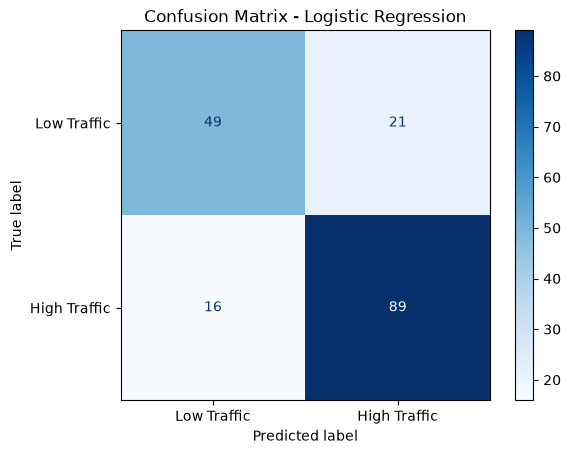

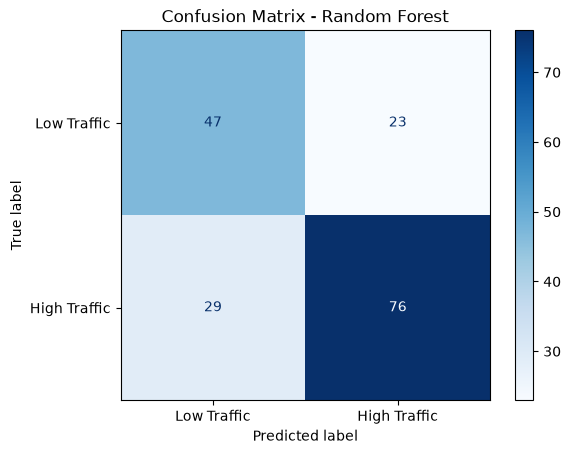

In [14]:
# Confusion matrices for both models
from sklearn.metrics import ConfusionMatrixDisplay
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    disp = ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=["Low Traffic", "High Traffic"],
        cmap='Blues',
        colorbar=True
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [15]:
# BUSINESS METRICS

'''Business wants: correctly predict popular recipes (High Recall)
AND minimize showing unpopular ones (High Precision)
So both Precision and Recall are business-relevant.''' 

def business_metric(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)
    return {'Precision': precision_score(y_true, y_pred),
            'Recall': recall_score(y_true, y_pred),
            'False Positive Rate': fpr}

print("\n--- Business Metrics ---")
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
print("Logistic Regression:", business_metric(y_test, y_pred_lr))
print("Random Forest:", business_metric(y_test, y_pred_rf))


--- Business Metrics ---
Logistic Regression: {'Precision': 0.8090909090909091, 'Recall': 0.8476190476190476, 'False Positive Rate': np.float64(0.3)}
Random Forest: {'Precision': 0.7676767676767676, 'Recall': 0.7238095238095238, 'False Positive Rate': np.float64(0.32857142857142857)}


In [16]:
#  FEATURE IMPORTANCE (for Random Forest)

rf = rf_model.named_steps['classifier']
ohe = rf_model.named_steps['preprocessor'].named_transformers_['cat']

# Combine numeric and one-hot encoded categorical feature names
feature_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))

# Get feature importances
importances = rf.feature_importances_

# Create a DataFrame and sort by importance
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=False).reset_index(drop=True)

# Display the top 10 important features
print("\nTop 10 Important Features:")
print(feat_imp.head(10))



Top 10 Important Features:
              Feature  Importance
0             protein    0.169090
1            calories    0.152105
2        carbohydrate    0.147793
3               sugar    0.146127
4  category_beverages    0.078731
5            servings    0.062431
6  category_vegetable    0.052451
7  category_breakfast    0.045066
8     category_potato    0.033175
9       category_pork    0.027026


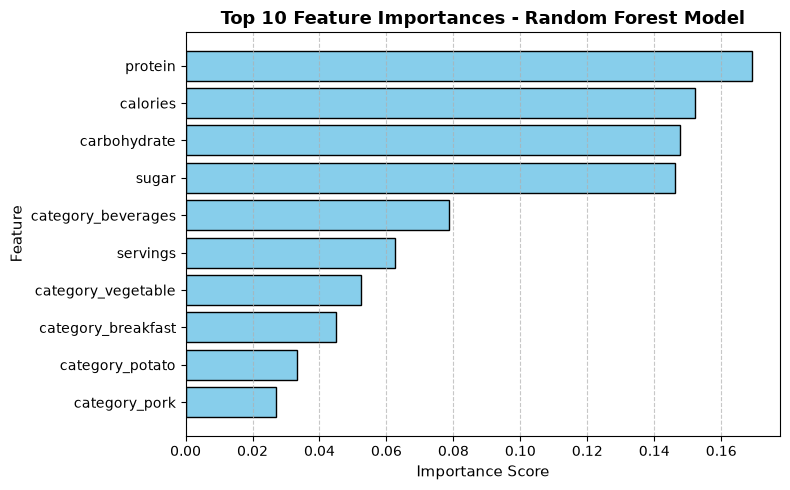

In [17]:
# Select top 10 features
top10 = feat_imp.head(10)

# Create horizontal bar chart
plt.figure(figsize=(8, 5))
plt.barh(top10['Feature'], top10['Importance'], color='skyblue', edgecolor='black')
plt.gca().invert_yaxis()  # Most important at the top
plt.title("Top 10 Feature Importances - Random Forest Model", fontsize=13, weight='bold')
plt.xlabel("Importance Score", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()